In [ ]:
# run before everything
%cd nn

### MNIST digits recognition

In [2]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torchvision import datasets

%matplotlib inline 

In [3]:
import src.utils.datasets as utils

In [4]:
transform = utils.create_transform()

train_ds = utils.load_torchvision_dataset(datasets.MNIST, train=True, transform=transform)
test_ds = utils.load_torchvision_dataset(datasets.MNIST, train=False, transform=transform)

In [5]:
def show_image(data):
    img, _ = data
    img_to_plot = img.squeeze(0)
    plt.imshow(img_to_plot, cmap="gray")
    plt.axis("off")
    plt.show()


image,_ = train_ds[0]
styled_df = utils.inspect_tensor_slice(image, row_slice=slice(4, 15), col_slice=slice(4, 22),)
styled_df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17
0,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
1,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.976471,-0.858824,-0.858824,-0.858824,-0.011765,0.066667,0.372549,-0.796078,0.301961,1.000000
2,-1.000000,-1.000000,-1.000000,-1.000000,-0.764706,-0.717647,-0.262745,0.207843,0.333333,0.984314,0.984314,0.984314,0.984314,0.984314,0.764706,0.349020,0.984314,0.898039
3,-1.000000,-1.000000,-1.000000,-0.615686,0.866667,0.984314,0.984314,0.984314,0.984314,0.984314,0.984314,0.984314,0.984314,0.968627,-0.270588,-0.356863,-0.356863,-0.560784
4,-1.000000,-1.000000,-1.000000,-0.858824,0.717647,0.984314,0.984314,0.984314,0.984314,0.984314,0.552941,0.427451,0.937255,0.890196,-1.000000,-1.000000,-1.000000,-1.000000
5,-1.000000,-1.000000,-1.000000,-1.000000,-0.372549,0.223529,-0.160784,0.984314,0.984314,0.607843,-0.913725,-1.000000,-0.662745,0.207843,-1.000000,-1.000000,-1.000000,-1.000000
6,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.890196,-0.992157,0.207843,0.984314,-0.294118,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
7,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,0.090196,0.984314,0.490196,-0.984314,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
8,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.913725,0.490196,0.984314,-0.450980,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
9,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-0.725490,0.890196,0.764706,0.254902,-0.152941,-0.992157,-1.000000,-1.000000,-1.000000,-1.000000


In [6]:
train_6_ds = utils.filter_dataset_by_classes(train_ds, target_classes=(6,))
train_7_ds = utils.filter_dataset_by_classes(train_ds, target_classes=(7,))
len(train_6_ds),len(train_7_ds)

(5918, 6265)

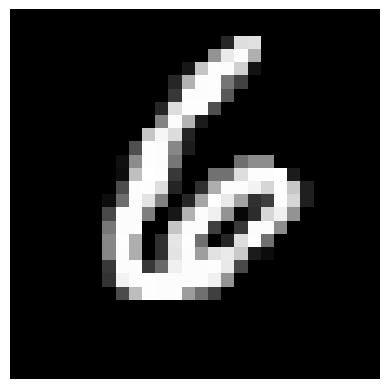

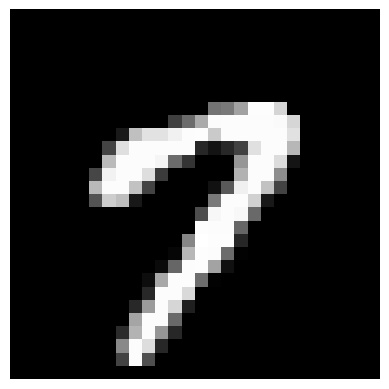

In [7]:
show_image(train_6_ds[0]); show_image(train_7_ds[0])

In [8]:
def stack_dataset_images(dataset) -> torch.Tensor:
    return torch.stack([dataset[i][0] for i in range(len(dataset))])    

stacked_sevens = stack_dataset_images(train_7_ds).float().squeeze(1) /255
stacked_sixs = stack_dataset_images(train_6_ds).float().squeeze(1) /255
stacked_sevens.shape

torch.Size([6265, 28, 28])

In [9]:
print(f"Rank: {len(stacked_sixs.shape)}", f"Dimensions: {stacked_sixs.ndim}")

Rank: 3 Dimensions: 3


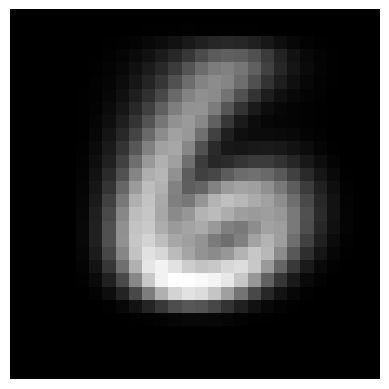

In [13]:
mean6 = stacked_sixs.mean(0)
mean7 = stacked_sevens.mean(0)
show_image((mean6, None));


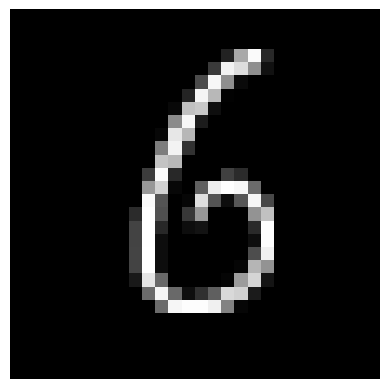

In [14]:
a = stacked_sixs[1]
show_image((a, None));

In [15]:
dist_6_abs = (a - mean6).abs().mean()
dist_6_sqr = ((a - mean6)**2).mean().sqrt()
dist_6_abs,dist_6_sqr

(tensor(0.0009), tensor(0.0017))

In [ ]:
dist_7_abs = (a - mean7).abs().mean()
dist_7_sqr = ((a - mean7)**2).mean().sqrt()
dist_7_abs,dist_7_sqr

(tensor(0.0011), tensor(0.0020))

In [17]:
F.l1_loss(a.float(),mean7), F.mse_loss(a,mean7).sqrt()

(tensor(0.0011), tensor(0.0020))

In [18]:
test_6_ds = utils.filter_dataset_by_classes(test_ds, target_classes=(6,))
test_7_ds = utils.filter_dataset_by_classes(test_ds, target_classes=(7,))
len(test_6_ds),len(test_7_ds)

(958, 1028)

In [19]:
stacked_sevens_valid = stack_dataset_images(test_7_ds).float().squeeze(1) /255
stacked_sixs_valid   = stack_dataset_images(test_6_ds).float().squeeze(1) /255
stacked_sevens_valid.shape

torch.Size([1028, 28, 28])

In [ ]:
def mnist_distance(a,b):
    return (a-b).abs().mean((-1,-2))

In [21]:
mnist_distance(a, mean6)

tensor(0.0009)

In [23]:
valid_3_dist = mnist_distance(stacked_sixs_valid, mean6)
valid_3_dist.shape

torch.Size([958])

In [26]:
def is_6(x): return mnist_distance(x,mean6) < mnist_distance(x,mean7)

In [27]:
is_6(a), is_6(a).float()

(tensor(True), tensor(1.))

In [28]:
accuracy_6s =      is_6(stacked_sixs_valid).float() .mean()
accuracy_7s = (1 - is_6(stacked_sevens_valid).float()).mean()

accuracy_6s,accuracy_7s,(accuracy_6s+accuracy_7s)/2

(tensor(0.9781), tensor(0.9912), tensor(0.9847))